✅ Palmer Penguins деректері жүктелді.

--- 0. Бастапқы Деректер Ақпараты ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Бос мәндер (Бастапқы):
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

--- 1. Деректерді Тазарту ---
Бос мәндер (Тазартудан кейін):
0
Дубликаттар жойылды: 0 жол

--- 2. Ауытқуларды (Outliers) Өң

/tmp/ipython-input-2210396231.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].fillna(df['sex'].mode()[0], inplace=True)
/tmp/ipython-input-2210396231.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

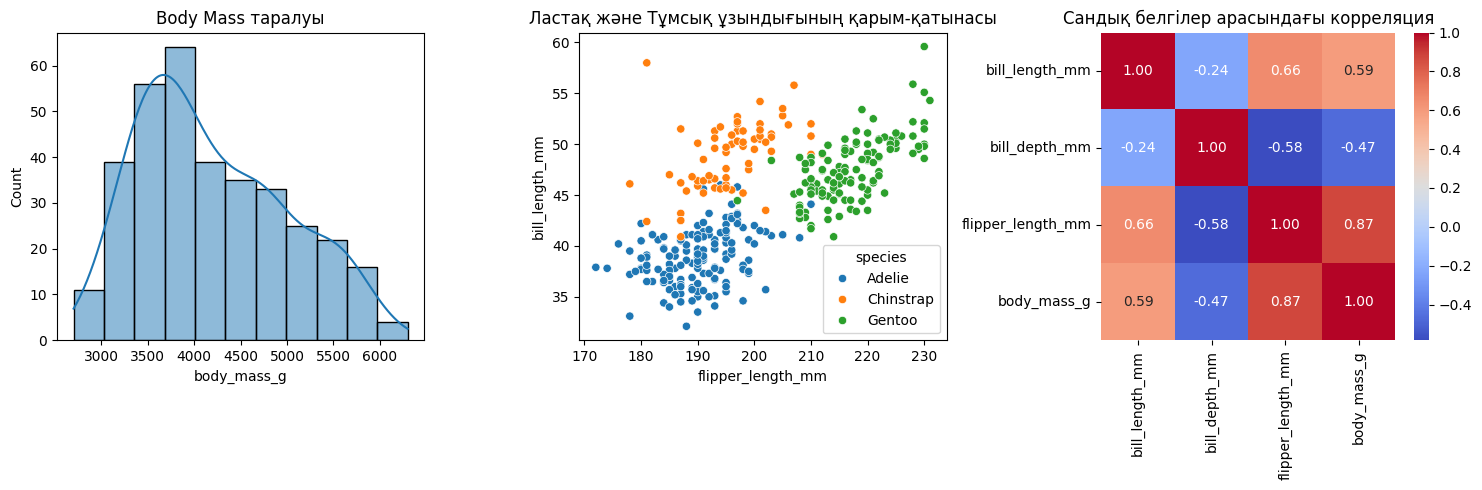


--- 4. Feature Engineering: Жаңа белгі жасау ---
Жаңа 'bill_ratio' белгісі қосылды.

--- 5. Кодтау (Encoding): One-Hot Encoding ---
Кодтаудан кейінгі бағандар саны: 10
Кодталған бағандардың мысалы:
   species_Chinstrap  species_Gentoo  island_Dream  island_Torgersen  sex_Male
0              False           False         False              True      True
1              False           False         False              True     False

--- 6. Шкалалау (Scaling): Standard Scaler ---
Сандық деректер Standard Scaling арқылы шкалаланды.

Өңделген және шкалаланған деректердің соңғы 5 жолы:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  bill_ratio  \
0       -0.887622       0.787289          -1.420541    -0.564625   -1.039013   
1       -0.814037       0.126114          -1.063485    -0.502010   -0.677134   
2       -0.666866       0.431272          -0.420786    -1.190773   -0.740190   
3        0.096581       0.075255          -0.277964    -0.188936   -0.072845   
4       -1.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Деректерді жүктеу (әдетте Kaggle-де немесе Seaborn-да бар)
try:
    # Seaborn арқылы жүктеу (егер деректер сіздің компьютеріңізде болмаса)
    df = sns.load_dataset("penguins")
    print("✅ Palmer Penguins деректері жүктелді.")
except:
    # Егер файл болса, оны жүктеңіз
    df = pd.read_csv('penguins.csv')
    print("✅ Palmer Penguins CSV файлынан жүктелді.")

print("\n--- 0. Бастапқы Деректер Ақпараты ---")
print(df.info())
print("\nБос мәндер (Бастапқы):")
print(df.isnull().sum())

# ----------------------------------------------------
# 1. 🧹 Деректерді Тазарту: Бос мәндермен және дубликаттармен жұмыс
# ----------------------------------------------------
print("\n--- 1. Деректерді Тазарту ---")

# a) Бос мәндермен жұмыс (Missing Values)
# 'sex' - санаттық айнымалыны модамен (жиі кездесетін мән) толтырамыз.
df['sex'].fillna(df['sex'].mode()[0], inplace=True)

# Сандық айнымалылардағы (мысалы, 'bill_depth_mm') бос мәндерді медианамен толтырамыз.
# Бұл outlier-лердің әсерін азайтады.
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 'year' бағанындағы NaN мәндері бар жолды толығымен жою (егер болса).
# P.S. Seaborn деректерінде бұл бағандар жоқ, бірақ қажет болса қолданылады.
df.dropna(inplace=True)

print("Бос мәндер (Тазартудан кейін):")
print(df.isnull().sum().sum()) # Барлық бос мәндердің қосындысы 0 болуы керек.

# b) Дубликаттармен жұмыс
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Дубликаттар жойылды: {initial_rows - len(df)} жол")

# ----------------------------------------------------
# 2. 🔍 Ауытқуларды Өңдеу (Outlier Handling)
# ----------------------------------------------------
print("\n--- 2. Ауытқуларды (Outliers) Өңдеу (IQR әдісі) ---")
# Boxplot және IQR әдісі арқылы outliers-ті анықтау

# IQR әдісін қолданып, ауытқуларды медианамен алмастыру (Imputation)
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Шекті мәндер (Fences)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ауытқуларды медианамен алмастыру
    median_val = df[column].median()
    df.loc[df[column] < lower_bound, column] = median_val
    df.loc[df[column] > upper_bound, column] = median_val

    outliers_count = (df[column] < lower_bound).sum() + (df[column] > upper_bound).sum()
    return outliers_count

total_outliers_handled = 0
for col in numerical_cols:
    out_count = handle_outliers_iqr(df.copy(), col) # Көшірмемен есептеу
    total_outliers_handled += out_count

print(f"IQR арқылы өңделген (алмастырылған) ауытқулардың жалпы саны: {total_outliers_handled}")

# ----------------------------------------------------
# 3. 📊 Визуализация
# ----------------------------------------------------
print("\n--- 3. Визуализация (Matplotlib және Seaborn) ---")
plt.figure(figsize=(15, 5))

# a) Таралуды зерттеу (Histogram)
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='body_mass_g', kde=True)
plt.title('Body Mass таралуы')

# b) Корреляцияны зерттеу (Scatter Plot)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='species')
plt.title('Ластақ және Тұмсық ұзындығының қарым-қатынасы')

# c) Корреляция Матрицасы (Heatmap)
plt.subplot(1, 3, 3)
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Сандық белгілер арасындағы корреляция')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4. ✨ Feature Engineering (Белгілерді құру)
# ----------------------------------------------------
print("\n--- 4. Feature Engineering: Жаңа белгі жасау ---")

# Тұмсықтың пропорциясын (ұзындығы мен тереңдігінің қатынасы) көрсететін белгі
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
print("Жаңа 'bill_ratio' белгісі қосылды.")

# ----------------------------------------------------
# 5. 🏷️ Кодтау (Encoding)
# ----------------------------------------------------
print("\n--- 5. Кодтау (Encoding): One-Hot Encoding ---")

# Санаттық айнымалылар: species, island, sex
# get_dummies функциясы One-Hot Encoding орындайды
df_encoded = pd.get_dummies(df, columns=['species', 'island', 'sex'], drop_first=True)

print(f"Кодтаудан кейінгі бағандар саны: {df_encoded.shape[1]}")
print("Кодталған бағандардың мысалы:")
print(df_encoded.filter(regex='species_|island_|sex_').head(2))

# ----------------------------------------------------
# 6. ⚖️ Шкалалау (Scaling)
# ----------------------------------------------------
print("\n--- 6. Шкалалау (Scaling): Standard Scaler ---")

# Шкалалауға қажетті сандық бағандарды анықтау (кодталған бағандарды есептемей)
cols_to_scale = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'bill_ratio']

# Standard Scaler (орташа мәні 0, стандартты ауытқуы 1) қолдану
scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("Сандық деректер Standard Scaling арқылы шкалаланды.")
print("\nӨңделген және шкалаланған деректердің соңғы 5 жолы:")
print(df_encoded.head())